In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer

In [38]:
data_path = Path('data', 'sleep_cycle_and_productivity.csv')
df = pd.read_csv(data_path)

In [39]:
df.columns

Index(['Date', 'Person_ID', 'Age', 'Gender', 'Sleep Start Time',
       'Sleep End Time', 'Total Sleep Hours', 'Sleep Quality',
       'Exercise (mins/day)', 'Caffeine Intake (mg)',
       'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)',
       'Productivity Score', 'Mood Score', 'Stress Level'],
      dtype='object')

In [40]:
df.describe()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5527.152200,38.590600,22.005350,4.980262,6.974902,5.520800,43.962600,146.71140,91.421200,7.987873,5.644200,5.370600,5.548000
std,2595.391771,12.302799,1.157591,1.862508,1.454033,2.863845,25.798541,85.83139,52.079123,2.275734,2.872221,2.835783,2.888419
min,1000.000000,18.000000,20.000000,0.560000,4.500000,1.000000,0.000000,0.00000,0.000000,4.000067,1.000000,1.000000,1.000000
25%,3258.000000,28.000000,21.020000,3.660000,5.690000,3.000000,22.000000,73.00000,46.000000,6.032720,3.000000,3.000000,3.000000
50%,5603.000000,39.000000,22.020000,4.970000,6.960000,5.000000,44.000000,144.00000,92.000000,7.998295,6.000000,5.000000,6.000000
75%,7749.500000,49.000000,23.000000,6.310000,8.210000,8.000000,66.000000,220.00000,136.000000,9.905024,8.000000,8.000000,8.000000
max,9998.000000,59.000000,23.980000,9.420000,9.500000,10.000000,89.000000,299.00000,179.000000,11.999141,10.000000,10.000000,10.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           5000 non-null   object 
 1   Person_ID                      5000 non-null   int64  
 2   Age                            5000 non-null   int64  
 3   Gender                         5000 non-null   object 
 4   Sleep Start Time               5000 non-null   float64
 5   Sleep End Time                 5000 non-null   float64
 6   Total Sleep Hours              5000 non-null   float64
 7   Sleep Quality                  5000 non-null   int64  
 8   Exercise (mins/day)            5000 non-null   int64  
 9   Caffeine Intake (mg)           5000 non-null   int64  
 10  Screen Time Before Bed (mins)  5000 non-null   int64  
 11  Work Hours (hrs/day)           5000 non-null   float64
 12  Productivity Score             5000 non-null   i

In [42]:
df.head()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2024-04-12,1860,32,Other,23.33,4.61,5.28,3,86,87,116,8.808920,8,3,6
1,2024-11-04,1769,41,Female,21.02,2.43,5.41,5,32,21,88,6.329833,10,3,7
2,2024-08-31,2528,20,Male,22.10,3.45,5.35,7,17,88,59,8.506306,10,9,10
3,2024-02-22,8041,37,Other,23.10,6.65,7.55,8,46,34,80,6.070240,8,4,2
4,2024-02-23,4843,46,Other,21.42,4.17,6.75,10,61,269,94,11.374994,8,7,9


### Clean the data

In [43]:
# Ensure Gender is treated as a string
df['Gender'] = df['Gender'].astype(str)

# Ensure Age is numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Define categorical and numerical columns explicitly
categorical_cols = ['Gender']
numerical_cols = ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours', 
                  'Sleep Quality', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 
                  'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 
                  'Mood Score', 'Stress Level']

In [44]:
X = df.drop(['Date', 'Person_ID', 'Productivity Score'], axis='columns')
y = df['Productivity Score']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

In [46]:
col_transformer = make_column_transformer(
    (OrdinalEncoder(categories=[['Other', 'Female', 'Male']]), ['Gender']),  # Encode Gender explicitly
    (StandardScaler(), ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours', 
                        'Sleep Quality', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 
                        'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 
                        'Mood Score', 'Stress Level'])
)

In [52]:
columns = categorical_cols + numerical_cols

X_train_transformed = pd.DataFrame(col_transformer.fit_transform(X_train), columns=columns)
X_test_transformed = pd.DataFrame(col_transformer.fit_transform(X_train), columns=columns)

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
linear = LinearRegression()

In [56]:
model = linear.fit(X_train_transformed, y_train)

In [57]:
cross_val_score(linear, X_train_transformed, y_train, cv=5)

array([-0.00204811, -0.00578953, -0.00029465,  0.00020559, -0.00794347])

In [60]:
X_train_transformed.corr()

,Gender,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Mood Score,Stress Level
Gender,1.000000,-0.007160,0.005065,0.009742,0.008591,-0.003746,0.016036,0.003809,-0.005785,0.012201,0.014518,0.006571
Age,-0.007160,1.000000,0.018972,0.008852,-0.003594,-0.012161,0.009952,-0.000220,-0.003505,0.018691,-0.008123,-0.021373
Sleep Start Time,0.005065,0.018972,1.000000,0.626892,0.013540,-0.005540,0.023284,0.008042,0.005087,0.007923,-0.025622,0.016509
Sleep End Time,0.009742,0.008852,0.626892,1.000000,0.787519,-0.003149,0.024148,0.017985,0.011893,-0.012387,-0.014355,0.007604
Total Sleep Hours,0.008591,-0.003594,0.013540,0.787519,1.000000,0.000294,0.012518,0.016702,0.011287,-0.022061,0.001861,-0.003321
Sleep Quality,-0.003746,-0.012161,-0.005540,-0.003149,0.000294,1.000000,-0.000820,0.007181,-0.006795,-0.020594,0.007667,-0.014049
Exercise (mins/day),0.016036,0.009952,0.023284,0.024148,0.012518,-0.000820,1.000000,0.017737,-0.016190,-0.008960,0.000994,-0.013343
Caffeine Intake (mg),0.003809,-0.000220,0.008042,0.017985,0.016702,0.007181,0.017737,1.000000,0.006093,0.009064,0.003262,0.001089
Screen Time Before Bed (mins),-0.005785,-0.003505,0.005087,0.011893,0.011287,-0.006795,-0.016190,0.006093,1.000000,0.009342,0.005563,-0.002658
Work Hours (hrs/day),0.012201,0.018691,0.007923,-0.012387,-0.022061,-0.020594,-0.008960,0.009064,0.009342,1.000000,0.030604,0.004868


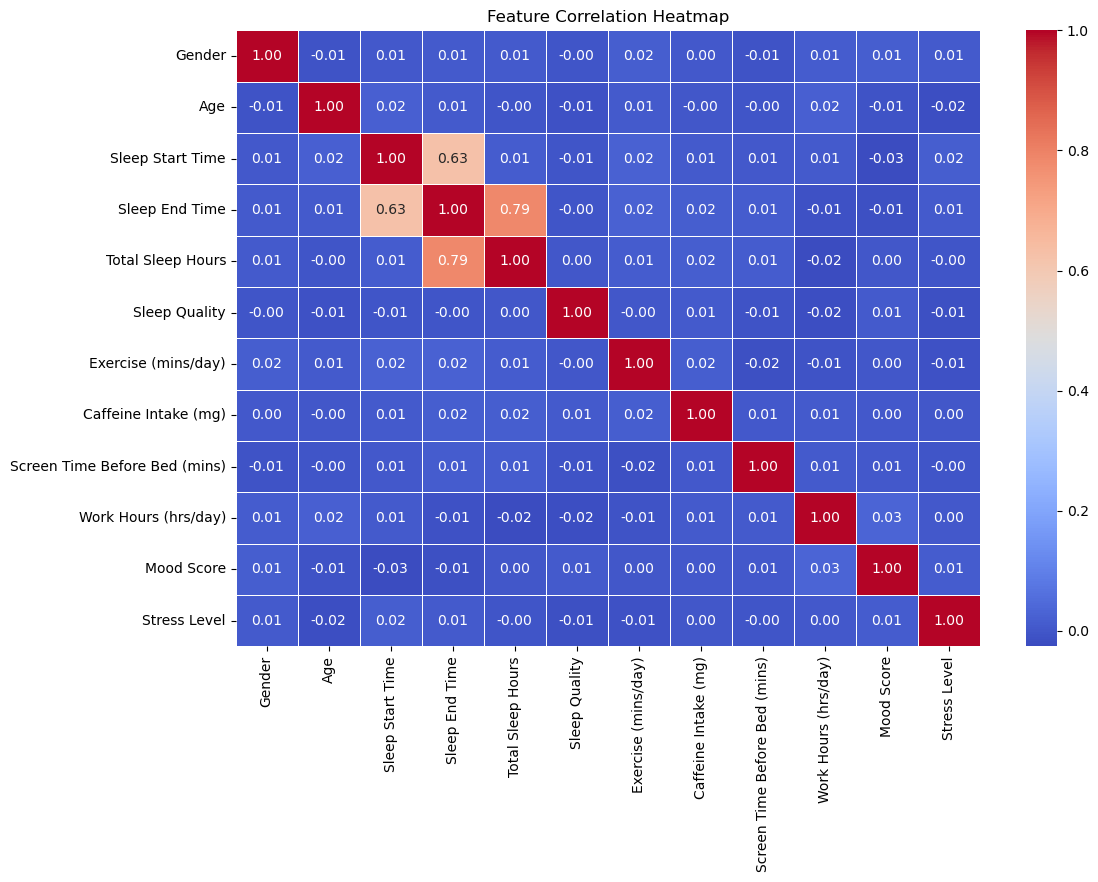

In [61]:

# Set figure size
plt.figure(figsize=(12, 8))

# Create a heatmap
sns.heatmap(X_train_transformed.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Show plot
plt.title("Feature Correlation Heatmap")
plt.show()